# 08 — Classification: Institutional Completion

**Chapter 10 companion.** Which institutional characteristics distinguish
institutions whose entering students complete at above-median rates for their
sector? This notebook works through the classification workflow: a
sector-relative target, a transparent baseline, cross-validated discrimination
and calibration, and an audit of how errors fall across institutions serving
different shares of low-income students.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet`: institutions reporting Outcome Measures |
| Target | `OM1TOTLAWDP8` (share of the 2015-16 entering cohort with any award within 8 years, [DRVOM2023](https://nces.ed.gov/ipeds/datacenter/data/DRVOM2023_Dict.zip)) above its sector median |
| Features | sector, admit rate plus an open-admission indicator, Pell and grant measures, staffing, online share, size, 12-month to fall ratio, student-faculty ratio |
| Methods | Regularised logistic regression, gradient boosting, stratified 5-fold CV, AUC, Brier score, log loss, calibration curves, subgroup error audit, feature ablation |

**What this is not.** Every row is an institution, and the target is an aggregate
outcome. Nothing here scores students or predicts whether any person will
complete, and it should not be used that way. The question is which institutional
conditions go with stronger completion, to inform resource and policy decisions.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. Target and features

Defining the target within sector removes the largest confounder by construction.
Two-year and four-year institutions differ in completion because of mission. A
national median would turn the classifier into a sector detector.

**Leakage check.** Every Outcome Measures field, graduation rate, and retention rate
is excluded from the features. They measure the same students' progress, so
including them would predict the outcome with itself. `PELL_GAP` is also excluded:
it is computed from Outcome Measures and serves only as a descriptive comparison.

In [3]:
frame = inst[inst["OM1TOTLAWDP8"].notna()].copy()
frame["sector_median"] = frame.groupby("SECTOR")["OM1TOTLAWDP8"].transform("median")
frame["above_median"] = (frame["OM1TOTLAWDP8"] > frame["sector_median"]).astype(int)
frame["open_admission"] = frame["ADMIT_RATE"].isna().astype(int)
frame["log_grant_amount"] = np.log10(frame["AGRNT_A"].where(frame["AGRNT_A"] > 0))
frame["log_undup_ug"] = np.log10(frame["UNDUPUG"].where(frame["UNDUPUG"] > 0))
frame["log_twelve_to_fall"] = np.log10(frame["TWELVE_TO_FALL"].where(frame["TWELVE_TO_FALL"] > 0))
frame["sector"] = frame["SECTOR_LABEL"].astype(str)

numeric = ["ADMIT_RATE", "open_admission", "UPGRNTP", "PGRNT_P", "log_grant_amount", "TENURE_DENSITY",
           "INSTR_FTE_SHARE", "PCTE12DEEXC", "log_undup_ug", "log_twelve_to_fall", "STUFACR"]
grant_features = ["UPGRNTP", "PGRNT_P", "log_grant_amount"]
frame = frame.set_index("UNITID")
y = frame["above_median"].to_numpy()
print(f"{len(frame):,} institutions; {y.mean():.1%} above their sector median "
      "(below 50% because ties at the median count as not above)")
frame.groupby("sector")["above_median"].agg(["size", "mean"]).rename(columns={"size": "institutions", "mean": "share above"})

3,492 institutions; 48.4% above their sector median (below 50% because ties at the median count as not above)


,institutions,share above
sector,,
"Private for-profit, 2-year",344,0.480
"Private for-profit, 4-year or above",231,0.494
"Private not-for-profit, 2-year",73,0.493
"Private not-for-profit, 4-year or above",1279,0.486
"Public, 2-year",789,0.468
"Public, 4-year or above",776,0.494


## 2. Two models under the same cross-validation

The logistic model imputes medians and standardises, so its coefficients are
comparable per standard deviation. Gradient boosting uses missing values natively.
Both see the same stratified folds. Out-of-fold predictions are kept, so every
later metric is computed on institutions the model was not trained on.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)


def logistic(cols):
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), cols),
        ("cat", OneHotEncoder(drop="first"), ["sector"])])
    return make_pipeline(prep, LogisticRegression(C=1.0, max_iter=2000))


def boosting(cols):
    prep = ColumnTransformer([("num", "passthrough", cols),
                              ("cat", OneHotEncoder(sparse_output=False), ["sector"])])
    return make_pipeline(prep, HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                              max_leaf_nodes=15, random_state=SEED))


def evaluate(model, cols):
    p = cross_val_predict(model, frame[[*cols, "sector"]], y, cv=cv, method="predict_proba")[:, 1]
    return p, {"AUC": roc_auc_score(y, p), "Brier": brier_score_loss(y, p), "log loss": log_loss(y, p)}


oof, scores = {}, {}
for name, factory in {"logistic": logistic, "gradient boosting": boosting}.items():
    oof[name], scores[name] = evaluate(factory(numeric), numeric)
scores["prevalence only"] = {"AUC": 0.5, "Brier": brier_score_loss(y, np.full(len(y), y.mean())),
                             "log loss": log_loss(y, np.full(len(y), y.mean()))}
pd.DataFrame(scores).T

,AUC,Brier,log loss
logistic,0.758,0.200,0.590
gradient boosting,0.811,0.176,0.525
prevalence only,0.500,0.250,0.693


Gradient boosting discriminates better than the logistic model (AUC 0.81 vs 0.76)
and has a lower Brier score. Part of the gap reflects non-linear effects and
interactions that a main-effects logistic model cannot represent.

## 3. Calibration

A good AUC means the model ranks institutions well, not that its probabilities mean
what they say. The calibration curve bins the out-of-fold predictions and compares
each bin's mean prediction with its observed share above the median.

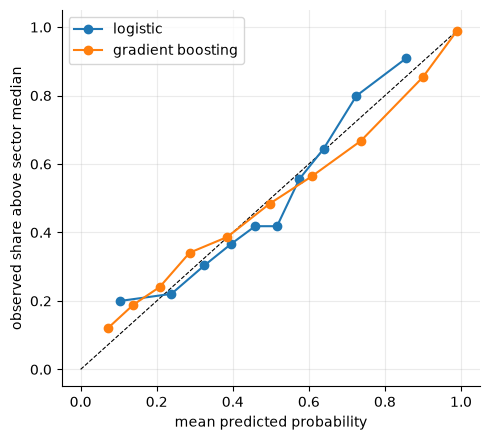

In [5]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
for name, p in oof.items():
    obs, pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    ax.plot(pred, obs, "o-", label=name)
ax.set(xlabel="mean predicted probability", ylabel="observed share above sector median")
ax.legend()
save("08_calibration")

## 4. What the logistic model uses

Coefficients are log-odds per standard deviation of each feature, holding the others
fixed. They describe associations among institutions, not causal effects.

In [6]:
fitted = logistic(numeric).fit(frame[[*numeric, "sector"]], y)
names = fitted[0].get_feature_names_out()
coefs = pd.Series(fitted[-1].coef_[0], index=[n.split("__", 1)[1] for n in names])
coefs.sort_values(key=np.abs, ascending=False).round(3).to_frame("log-odds per SD")

,log-odds per SD
"sector_Private not-for-profit, 4-year or above",-1.997
"sector_Public, 4-year or above",-1.574
"sector_Public, 2-year",-0.522
PCTE12DEEXC,-0.518
PGRNT_P,-0.497
open_admission,-0.426
log_grant_amount,0.327
log_undup_ug,0.315
UPGRNTP,-0.168
"sector_Private for-profit, 4-year or above",0.166


The sector dummies are large even though every sector sits near 50% above its median.
That is not a contradiction. The features differ sharply between sectors: four-year
nonprofits have little online enrollment and fewer open-admission institutions, both
of which predict "above" in the pooled model. The dummies offset those level
differences, so the remaining coefficients describe variation within sector. Among
the institutional features, a high share of students enrolled exclusively online,
a high first-time Pell share, and open admission go with lower relative completion.
Larger grant aid per recipient and larger enrollment go with higher completion.

## 5. Error audit by Pell share

Even an institution-level model can distribute its mistakes unevenly. If the model
systematically misclassifies institutions that serve many low-income students, any
decision built on it inherits that pattern. The audit splits institutions into
terciles of undergraduate Pell share (`UPGRNTP`) and compares error rates at a 0.5
threshold.

In [7]:
tercile = pd.qcut(frame["UPGRNTP"], 3, labels=["low Pell", "middle", "high Pell"])


def audit(p):
    pred = (p >= 0.5).astype(int)
    rows = {}
    for t in tercile.cat.categories:
        m = (tercile == t).to_numpy()
        yt, pt = y[m], pred[m]
        rows[t] = {"institutions": int(m.sum()), "share above median": yt.mean(),
                   "mean predicted": p[m].mean(),
                   "false positive rate": ((pt == 1) & (yt == 0)).sum() / max((yt == 0).sum(), 1),
                   "false negative rate": ((pt == 0) & (yt == 1)).sum() / max((yt == 1).sum(), 1)}
    return pd.DataFrame(rows).T


audit(oof["gradient boosting"])

,institutions,share above median,mean predicted,false positive rate,false negative rate
low Pell,"1,241.000",0.638,0.645,0.356,0.164
middle,"1,084.000",0.447,0.442,0.217,0.390
high Pell,"1,162.000",0.351,0.344,0.153,0.512


Read the base rates first. If high-Pell institutions are less often above their
sector median, a well-calibrated model will predict "above" for them less often.
Their false-negative rate can then rise without any bias in the model itself. Error
rates that differ across groups with different base rates are expected. Deciding
which error rate should be equalised is a policy choice, not a statistical one.

## 6. Ablation: remove the Pell and grant features

Dropping the features that measure students' financial need shows how much the model
relies on the composition of the student body, as opposed to institutional
practice. It also shows whether that reliance drives the error pattern above.

In [8]:
reduced = [c for c in numeric if c not in grant_features]
oof["boosting without grant features"], scores["boosting without grant features"] = evaluate(boosting(reduced), reduced)
print(pd.DataFrame(scores).T.loc[["gradient boosting", "boosting without grant features"]].round(3))
audit(oof["boosting without grant features"])

                                  AUC  Brier  log loss
gradient boosting               0.811  0.176     0.525
boosting without grant features 0.773  0.193     0.568


,institutions,share above median,mean predicted,false positive rate,false negative rate
low Pell,"1,241.000",0.638,0.562,0.234,0.270
middle,"1,084.000",0.447,0.446,0.222,0.400
high Pell,"1,162.000",0.351,0.435,0.263,0.495


Removing the grant features costs discrimination (AUC 0.81 to 0.77) and does not fix
the audit. The false-negative rate for high-Pell institutions stays near 50%, and
false positives rise. Calibration within groups gets worse: the reduced model
predicts 0.44 on average for high-Pell institutions whose observed share is 0.35. A
model that cannot see need uses proxies for it, less accurately. Dropping a
sensitive feature is not a fairness method, and removing it can make things worse.

## 7. The Pell completion gap, descriptively

`PELL_GAP` compares completion for Pell recipients and non-recipients within the
same institution. It is summarised here as a description, not a model input.

In [9]:
frame.groupby("sector")["PELL_GAP"].describe()[["count", "25%", "50%", "75%"]].round(1)

,count,25%,50%,75%
sector,,,,
"Private for-profit, 2-year",327.000,-11.500,-1.000,8.500
"Private for-profit, 4-year or above",209.000,-12.000,0.000,14.000
"Private not-for-profit, 2-year",55.000,-7.000,0.000,11.500
"Private not-for-profit, 4-year or above","1,182.000",-14.800,-8.000,-1.000
"Public, 2-year",787.000,-13.000,-7.000,-2.000
"Public, 4-year or above",771.000,-12.500,-8.000,-3.000


Negative values mean Pell recipients complete at lower rates than other students at
the same institution. The median gap is about 7 to 8 points in public institutions
and four-year nonprofits, and close to zero in for-profit and two-year nonprofit
institutions. Whether a small gap reflects equitable support or uniformly low
completion needs the level alongside the gap.

## Exercises

1. Replace the within-sector median with the within-sector top quartile. How do AUC
   and the calibration curve change when the positive class is rarer?
2. Choose a threshold per Pell tercile that equalises false-negative rates. What
   happens to the false-positive rates?
3. Group the folds by state with `GroupKFold`. Does performance hold when the model
   has to generalise to states it has not seen?